In [ ]:
%pip install nnfs
%pip install matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


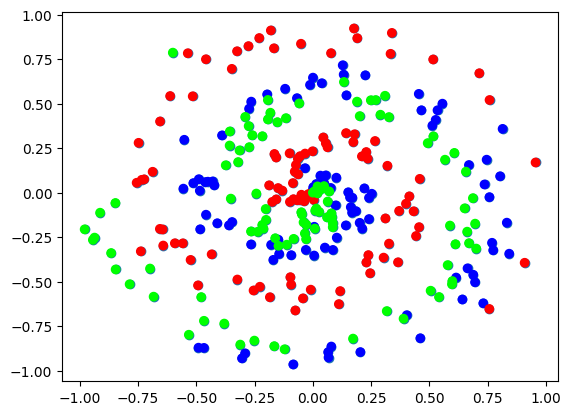

In [2]:
import nnfs
from nnfs.datasets import spiral_data

X,y = spiral_data(100,3)    # X contains coordinates and y contains class labels

plt.scatter(X[:,0],X[:,1]) # plot the 100 data points

plt.scatter(X[:,0],X[:,1],c=y,cmap='brg') # plot the 100 points , with class representation using colors

In [3]:
from sklearn.preprocessing import OneHotEncoder
y_true = pd.get_dummies(y,dtype='int')
print(y_true)

     0  1  2
0    1  0  0
1    1  0  0
2    1  0  0
3    1  0  0
4    1  0  0
..  .. .. ..
295  0  0  1
296  0  0  1
297  0  0  1
298  0  0  1
299  0  0  1

[300 rows x 3 columns]


In [4]:
# implementing a simple forward pass without the loss functions
# the flow is :
# take 2 inputs (X,y) coordinates -> get weighted sum using 3 neurons -> ReLU(weighted sum) -> get weighted sum using 3 neurons -> Softmax(weighted_sum2)

In [5]:
class DenseLayer:
  def __init__(self,n_inputs,n_neurons) -> None:    # take the number of inputs and number of neurons in the layer
    self.weights = 0.01*np.random.randn(n_neurons,n_inputs)   # initialize weights with small random numbers , shape of weight matrix (n_neurons in current layer ,number of neurons in the previous layer)
    self.bias = np.zeros((1,n_neurons))  # initialize bias with 0

  def forwardpass(self,X):
    # weighted sum
    self.weighted_sum = X@self.weights.T+self.bias
    return self.weighted_sum

class ReLU:
  def forward(self,weighted_sum):
    return np.maximum(0,weighted_sum)

class Softmax:
  def forward(self,weighted_sum):
    # subtract the maximum of each row from each number
    shifted = weighted_sum - np.max(weighted_sum ,axis =1 , keepdims = True)
    # get exponents of each value
    exp_weighted_sum = np.exp(shifted)
    return exp_weighted_sum / np.sum(exp_weighted_sum,axis=1,keepdims=True)

class CategoricalCrossEntropy:
  def forward(self,softmax_output,true_labels):
    # clip to prevent log(0)
    clipped = np.clip(softmax_output,1e-7,1-1e-7)
    corrected_confidence = np.sum(clipped*true_labels,axis=1)
    negative_log_likelihood = -np.log(corrected_confidence)
    return np.mean(negative_log_likelihood)


In [6]:
dense1= DenseLayer(2,3)
dense2 =DenseLayer(3,3)
relu = ReLU()
softmax = Softmax()
loss_function =  CategoricalCrossEntropy()

z1 = dense1.forwardpass(X)
act_z1 = relu.forward(z1)
z2 = dense2.forwardpass(act_z1)
y_pred = softmax.forward(z2)
loss = loss_function.forward(y_pred,y_true)
print(loss)

1.09861347881329
